## 1 - Business Understanding (Aufgabendefinition) 
- Bestimmung der betriebswirtschaftlichen Problemstellung
- Situationsbewertung
- Bestimmung analytischer Ziele
- Erstellung eines Projektplans
- ---

### Bestimmung der betriebswirtschaftlichen Problemstellung
Ein Gebrauchtwagenhändler (GWH) möchte den Preis für verfügbare Gebrauchtwagen mittels eines Modells bestimmen. Bisher wird der Preis auf Basis der Erfahrungswerte der Mitarbeiter bestimmt. Der Preis soll für die Kunden und im Vergleich zum Markt akzeptabel sein und gleichzeitig eine hohe Marge für den Händler einbringen. Durch den Einsatz einer datenbasierten Entscheidungsunterstützung soll gezeigt werden, ob es Potenzial für höhere Margen gibt. 
### Situationsbewertung
Der GWH hat Daten über verkaufte Gebrauchtwagen über die Plattform kaggle bezogen. Die Grundlage für eine Datenanalyse ist damit vorhanden. Der aktuelle Prozess ist stark von der Erfahrung der jeweiligen Mitarbeiter abhängig. Ein datenbasierter und systemgestützter Prozess könnte diese starke Abhängigkeit entlasten und die Mitarbeiter bei Ihren Entscheidungen unterstützen. Es besteht die Chance neue Erkenntnisse aus Daten zu erlangen und bisher ungenutzte Potenziale zu heben.
### Bestimmung analytischer Ziele
Identifizierung von Assoziationen in den Daten und deren Einfluss auf das Ziel-Attribut „Preis“ 
### Erstellung eines Projektplans
Zusammenstellen eines Teams (Rollen, Verantwortungen festlegen)
Vorgehen nach den CRISP-DM (Phasen und Dauer planen)
Ergebnisse dem Auftraggeber präsentieren

---

## 2 - Data Understanding (Datenverständniss)
- Daten sammeln
- Daten beschreiben
- Untersuchung der Daten
- Verifizierung der Datenqualität
- ---

### 2.1 Daten sammeln

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Data: Based on Used Car data from https://www.kaggle.com/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/data

In [2]:
# Import Data sets

df = pd.read_csv("audi.csv")
#df = pd.read_csv("bmw.csv")
#df = pd.read_csv("ford.csv")

### 2.2 Daten beschreiben

In [8]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10668 entries, 0 to 10667
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10668 non-null  object 
 1   year          10668 non-null  int64  
 2   price         10668 non-null  int64  
 3   transmission  10668 non-null  object 
 4   mileage       10668 non-null  int64  
 5   fuelType      10668 non-null  object 
 6   tax           10668 non-null  int64  
 7   mpg           10668 non-null  float64
 8   engineSize    10668 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 750.2+ KB


In [10]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [11]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,10668.000000,10668.000000,10668.000000,10668.000000,10668.000000,10668.000000
mean,2017.100675,22896.685039,24827.244001,126.011436,50.770022,1.930709
std,2.167494,11714.841888,23505.257205,67.170294,12.949782,0.602957
min,1997.000000,1490.000000,1.000000,0.000000,18.900000,0.000000
25%,2016.000000,15130.750000,5968.750000,125.000000,40.900000,1.500000
50%,2017.000000,20200.000000,19000.000000,145.000000,49.600000,2.000000
75%,2019.000000,27990.000000,36464.500000,145.000000,58.900000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,188.300000,6.300000


In [12]:
df.shape

(10668, 9)

### 2.3 Untersuchung der Daten (EDA)

### Univariate Analysis

In [16]:
def skalenniveau_bestimmen(df):
    if df.dtype == 'object':  # Kategorische Daten
        # Falls es nur wenige eindeutige Werte gibt, könnte es Nominal oder Ordinal sein.
        unique_values = df.nunique()
        if unique_values <= 10:
            return "Nominal (kategorisch)"
        else:
            return "Ordinal (Reihenfolge vorhanden)"
    
    elif pd.api.types.is_numeric_dtype(df):
        if (df.min() == 0) and (df.max() > 0):  # Echte Null vorhanden (Verhältnisskala)
            return "Verhältnisskala"
        else:  # Intervalldaten
            return "Intervallskala"
    
    return "Unklar"

# Beispiel anwenden
print('model', skalenniveau_bestimmen(df['model']))  # Nominal
print('year', skalenniveau_bestimmen(df['year']))  # Verhältnisskala
print('price', skalenniveau_bestimmen(df['price']))  # Ordinal
print('transmission', skalenniveau_bestimmen(df['transmission']))  # Nominal
print('mileage', skalenniveau_bestimmen(df['mileage']))  # Verhältnisskala
print('fuelType', skalenniveau_bestimmen(df['fuelType']))  # Nominal
print('tax', skalenniveau_bestimmen(df['tax']))  # Verhältnisskala
print('mpg', skalenniveau_bestimmen(df['mpg']))  # Verhältnisskala
print('engineSize', skalenniveau_bestimmen(df['engineSize']))  # Verhältnisskala

model Ordinal (Reihenfolge vorhanden)
year Intervallskala
price Intervallskala
transmission Nominal (kategorisch)
mileage Intervallskala
fuelType Nominal (kategorisch)
tax Verhältnisskala
mpg Intervallskala
engineSize Verhältnisskala


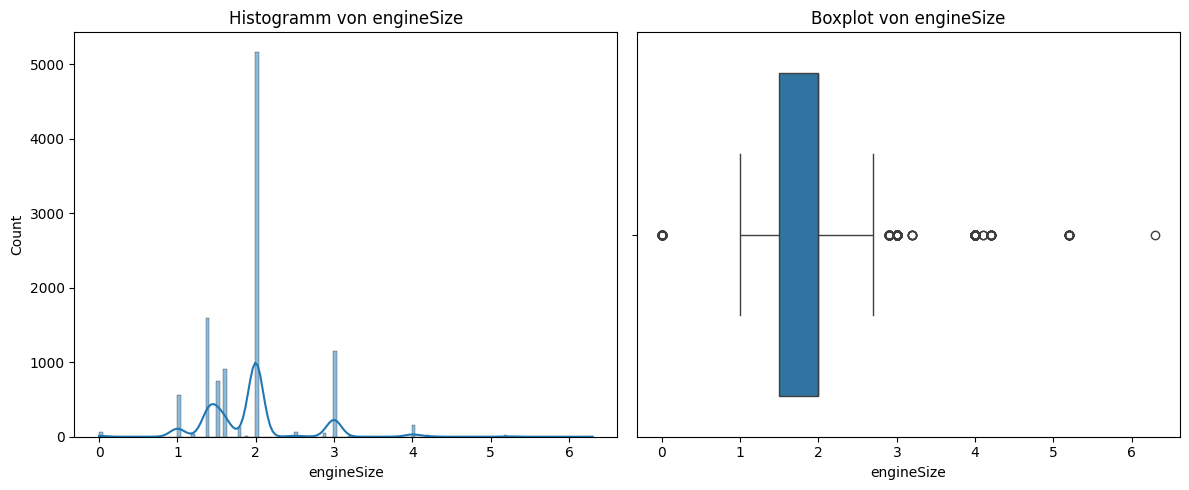

In [37]:
# Histogramm & Boxplot for numerical variables
#num_col = "year"  
#num_col = "price" 
#num_col = "mileage"  
#num_col = "tax"  
#num_col = "mpg"  
num_col = "engineSize"

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[num_col], kde=True)
plt.title(f'Histogramm von {num_col}')

plt.subplot(1, 2, 2)
sns.boxplot(x=df[num_col])
plt.title(f'Boxplot von {num_col}')

plt.tight_layout()
plt.show()

model
A3     1929
Q3     1417
A4     1381
A1     1347
A5      882
Q5      877
Q2      822
A6      748
Q7      397
TT      336
A7      122
A8      118
Q8       69
RS6      39
RS3      33
RS4      31
RS5      29
R8       28
S3       18
SQ5      16
S4       12
SQ7       8
S8        4
S5        3
A2        1
RS7       1
Name: count, dtype: int64


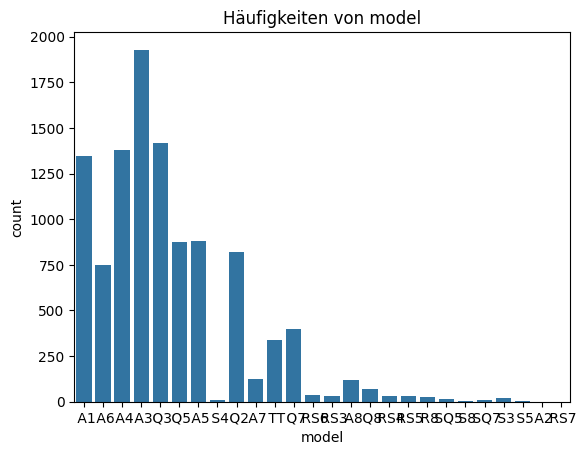

In [30]:
# for nomminal variables
cat_col = "model"
#cat_col = "transmission" 
#cat_col = "fuelType"  

print(df[cat_col].value_counts())

# Balkendiagramm
sns.countplot(x=df[cat_col])
plt.title(f'Häufigkeiten von {cat_col}')
plt.show()


### Bivariate Analysis

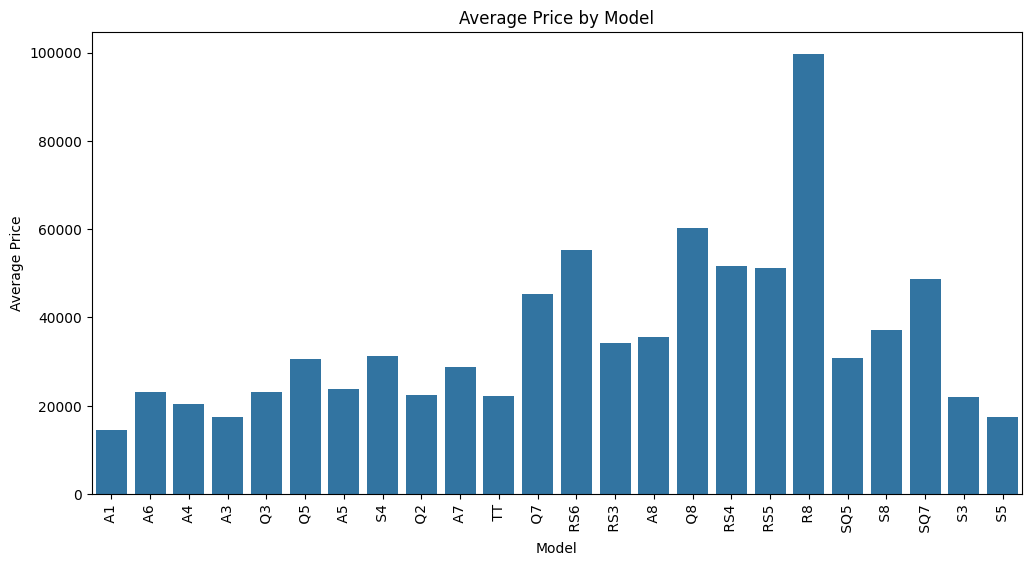

In [20]:
plt.figure(figsize=(12, 6))
sns.barplot(x='model', y='price', data=df[:10000], errorbar=None)
plt.title('Average Price by Model')
plt.xlabel('Model')
plt.ylabel('Average Price')
plt.xticks(rotation=90)  
plt.show()

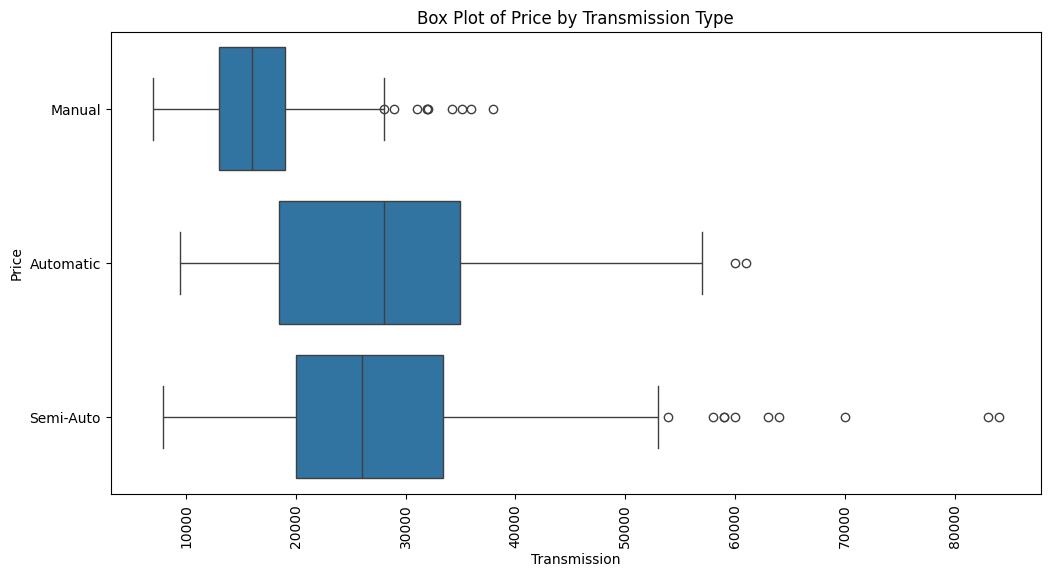

In [21]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='price', y='transmission', data=df[:1000],orient='h')
plt.title('Box Plot of Price by Transmission Type')
plt.xlabel('Transmission')
plt.ylabel('Price')
plt.xticks(rotation=90) 
plt.show()

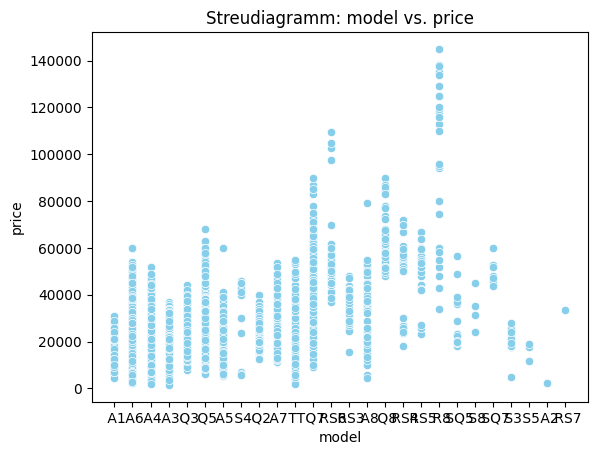

In [23]:
import seaborn as sns

# Streudiagramm mit seaborn erstellen
sns.scatterplot(data=df, x='model', y='price', color='skyblue')

# Titel hinzufügen
plt.title('Streudiagramm: model vs. price')

# Diagramm anzeigen
plt.show()

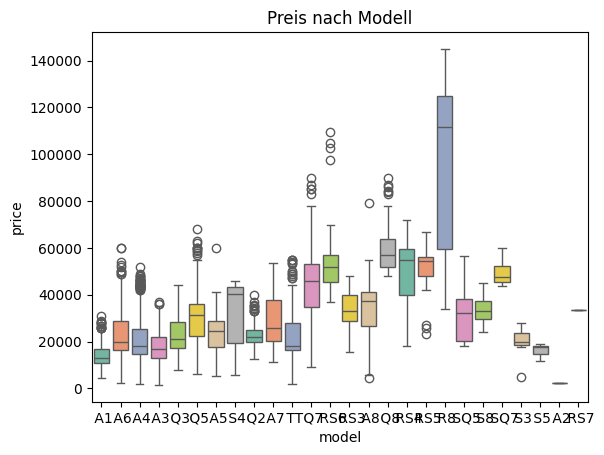

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot erstellen mit hue anstelle von palette
sns.boxplot(x='model', y='price', data=df, hue='model', palette='Set2', legend=False)

# Titel hinzufügen
plt.title('Preis nach Modell')

# Diagramm anzeigen
plt.show()

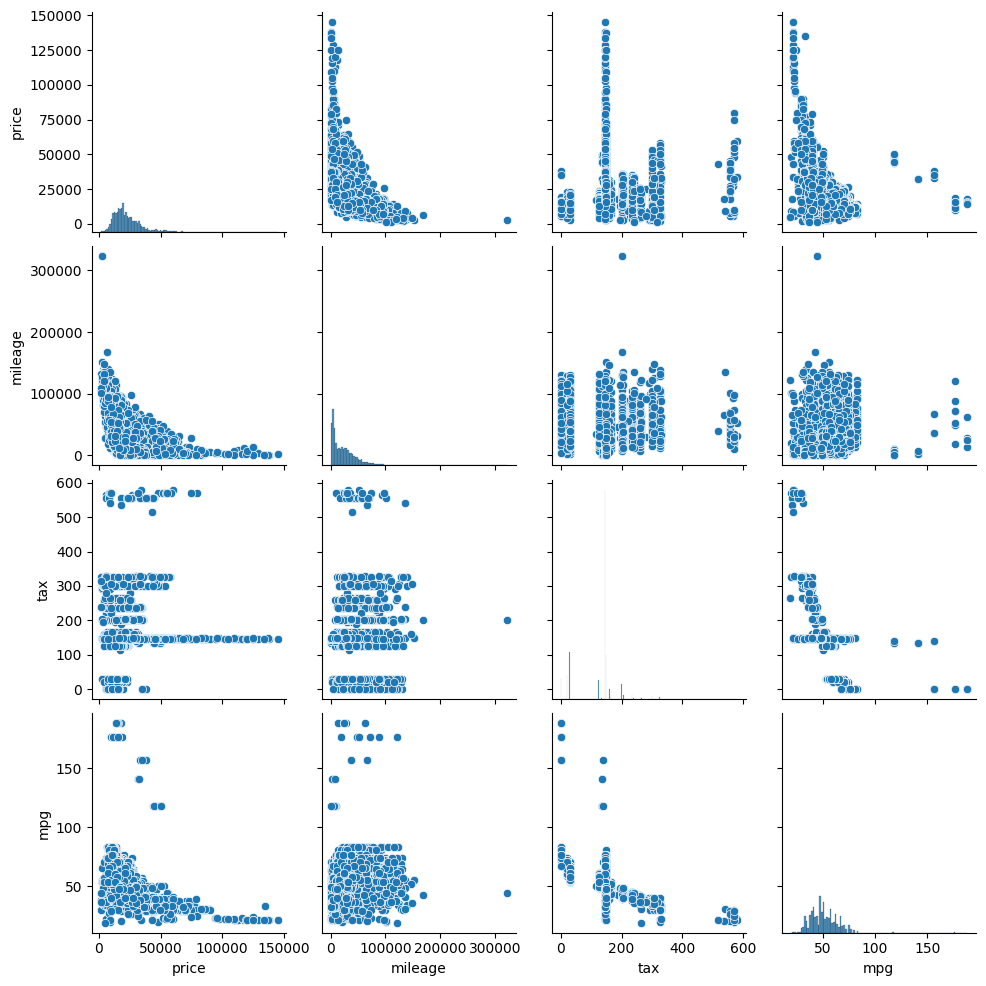

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pairplot für price und mileage
sns.pairplot(df[['price', 'mileage', 'tax', 'transmission', 'mpg']])

# Diagramm anzeigen
plt.show()

### 2.4 Verifizierung der Datenqualität

In [4]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [5]:
# how many total missing values do we have?
total_cells = np.prod(df.shape)
total_missing = df.isnull().sum()

# percent of data that is missing
percent_missing = (total_missing/total_cells) * 100
print(percent_missing)

model           0.0
year            0.0
price           0.0
transmission    0.0
mileage         0.0
fuelType        0.0
tax             0.0
mpg             0.0
engineSize      0.0
dtype: float64


In [50]:
df.dropna()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Cluster
0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4,3
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,4
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,4
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,3
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,1
...,...,...,...,...,...,...,...,...,...,...
10663,A3,2020,16999,Manual,4018,Petrol,145,49.6,1.0,1
10664,A3,2020,16999,Manual,1978,Petrol,150,49.6,1.0,1
10665,A3,2020,17199,Manual,609,Petrol,150,49.6,1.0,1
10666,Q3,2017,19499,Automatic,8646,Petrol,150,47.9,1.4,1


In [54]:
columns_with_na_dropped = df.dropna(axis=1)
columns_with_na_dropped.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Cluster
0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4,3
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,4
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,4
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,3
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,1


In [55]:
# just how much data did we lose?
print("Columns in original dataset: %d \n" % df.shape[1])
print("Columns with na's dropped: %d" % columns_with_na_dropped.shape[1])

Columns in original dataset: 10 

Columns with na's dropped: 10


In [56]:
df.fillna(0)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Cluster
0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4,3
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,4
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,4
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,3
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,1
...,...,...,...,...,...,...,...,...,...,...
10663,A3,2020,16999,Manual,4018,Petrol,145,49.6,1.0,1
10664,A3,2020,16999,Manual,1978,Petrol,150,49.6,1.0,1
10665,A3,2020,17199,Manual,609,Petrol,150,49.6,1.0,1
10666,Q3,2017,19499,Automatic,8646,Petrol,150,47.9,1.4,1


In [6]:
df.duplicated().sum()

np.int64(103)

In [7]:
# Duplikate anzeigen (alle Spalten vergleichen)
duplikate = df[df.duplicated()]
print("Einfache Duplikate:")
print(duplikate)

Einfache Duplikate:
     model  year  price transmission  mileage fuelType  tax   mpg  engineSize
273     Q3  2019  34485    Automatic       10   Diesel  145  47.1         2.0
764     Q2  2019  22495       Manual     1000   Diesel  145  49.6         1.6
784     Q3  2015  13995       Manual    35446   Diesel  145  54.3         2.0
967     Q5  2019  31998    Semi-Auto      100   Petrol  145  33.2         2.0
990     Q2  2019  22495       Manual     1000   Diesel  145  49.6         1.6
...    ...   ...    ...          ...      ...      ...  ...   ...         ...
9508    A4  2019  26990    Automatic     2250   Diesel  145  50.4         2.0
9521    Q3  2019  26990       Manual       10   Petrol  145  40.9         1.5
9529    Q5  2019  44990    Automatic       10   Diesel  145  36.2         2.0
9550    Q3  2019  29995       Manual       10   Petrol  145  39.8         1.5
9597    Q3  2019  28490       Manual       10   Diesel  145  42.8         2.0

[103 rows x 9 columns]


In [8]:
# Duplikate inklusive des ersten Auftretens anzeigen
duplikate_mit_erstem = df[df.duplicated(keep=False)]
print("\nAlle Duplikate (inkl. erstes Vorkommen):")
print(duplikate_mit_erstem)


Alle Duplikate (inkl. erstes Vorkommen):
     model  year  price transmission  mileage fuelType  tax   mpg  engineSize
231     Q3  2019  34485    Automatic       10   Diesel  145  47.1         2.0
273     Q3  2019  34485    Automatic       10   Diesel  145  47.1         2.0
277     Q5  2019  31998    Semi-Auto      100   Petrol  145  33.2         2.0
567     Q3  2015  13995       Manual    35446   Diesel  145  54.3         2.0
727     Q2  2019  22495       Manual     1000   Diesel  145  49.6         1.6
...    ...   ...    ...          ...      ...      ...  ...   ...         ...
9524    Q5  2019  44990    Automatic       10   Diesel  145  36.2         2.0
9529    Q5  2019  44990    Automatic       10   Diesel  145  36.2         2.0
9549    Q3  2019  29995       Manual       10   Petrol  145  39.8         1.5
9550    Q3  2019  29995       Manual       10   Petrol  145  39.8         1.5
9597    Q3  2019  28490       Manual       10   Diesel  145  42.8         2.0

[185 rows x 9 columns

In [13]:
df_cleaned = df.drop_duplicates()

---
## 3 - Data Preparation (Datenaufbereitung)
- Auswahl der Daten
- Bereinigung der Daten
- Transformation und Integration der Daten
- Datenformatierung
- ---

### 3.1 Auswahl der Daten

### 3.2 Bereinigung der Daten

In [5]:
df_cleaned = df.drop_duplicates()

### Fixe Klassen mit pd.cut():

### Quantile-basierte Klassen mit pd.qcut() (z. B. gleiche Anzahl pro Gruppe):

In [10]:
#df['price_group'] = pd.qcut(df['price'], q=3, labels=['jung', 'mittel', 'alt'])
df['price_group'] = pd.qcut(df['price'], q=3, labels=['niedrig', 'mittel', 'hoch'])

print (df['price_group'])

0        niedrig
1        niedrig
2        niedrig
3        niedrig
4         mittel
          ...   
10663     mittel
10664     mittel
10665     mittel
10666     mittel
10667    niedrig
Name: price_group, Length: 10668, dtype: category
Categories (3, object): ['niedrig' < 'mittel' < 'hoch']


In [18]:
df['year_group'] = pd.cut(df['year'], bins=[0, 2016, 2017, 2018, 2019, 2020], labels=['2016', '2017', '2018', '2019', '2020'])
#df['price_group'] = pd.cut(df['price'], bins=[0, 3500, 4500, 6000], labels=['<3500', '3500-4500', '>4500'])

print (df['year_group'])

0        2017
1        2016
2        2016
3        2017
4        2019
         ... 
10663    2020
10664    2020
10665    2020
10666    2017
10667    2016
Name: year_group, Length: 10668, dtype: category
Categories (5, object): ['2016' < '2017' < '2018' < '2019' < '2020']


### 3.3  Transformation und Integration der Daten

In [28]:
df_encoded = pd.get_dummies(df[['price_group', 'model', 'year_group', 'transmission',  'fuelType']])

print (df_encoded)

       price_group_niedrig  price_group_mittel  price_group_hoch  model_ A1  \
0                     True               False             False       True   
1                     True               False             False      False   
2                     True               False             False       True   
3                     True               False             False      False   
4                    False                True             False      False   
...                    ...                 ...               ...        ...   
10663                False                True             False      False   
10664                False                True             False      False   
10665                False                True             False      False   
10666                False                True             False      False   
10667                 True               False             False      False   

       model_ A2  model_ A3  model_ A4  model_ A5  

### 3.4 Datenformatierung

---
## 4 - Modeling (Modellierung)
- Auswahl des Modells
- Testmodell erstellen
- Modell erstellen
- ---

### 4.1  Auswahl des Modells

### 4.2 Testmodell erstellen

### 4.3 Modell erstellen

### einfaches Modell ohne transformationen

In [40]:
from mlxtend.frequent_patterns import apriori

# Mindestunterstützung (support) z. B. 0.5 = 50 %
frequent_itemsets = apriori(df_encoded, min_support=0.2, use_colnames=True)
print(frequent_itemsets)


     support                                    itemsets
0   0.335583                       (price_group_niedrig)
1   0.335208                        (price_group_mittel)
2   0.329209                          (price_group_hoch)
3   0.370829                           (year_group_2016)
4   0.299681                           (year_group_2019)
5   0.253843                    (transmission_Automatic)
6   0.409543                       (transmission_Manual)
7   0.336614                    (transmission_Semi-Auto)
8   0.522778                           (fuelType_Diesel)
9   0.474597                           (fuelType_Petrol)
10  0.262373      (price_group_niedrig, year_group_2016)
11  0.245876  (price_group_niedrig, transmission_Manual)
12  0.201069         (price_group_hoch, year_group_2019)
13  0.210724      (transmission_Manual, year_group_2016)
14  0.238751          (fuelType_Diesel, year_group_2016)
15  0.210911      (transmission_Manual, fuelType_Petrol)


In [41]:
from mlxtend.frequent_patterns import association_rules
pd.set_option('display.max_columns', None)  # zeigt alle Spalten
pd.set_option('display.expand_frame_repr', False)  # verhindert automatischen Umbruch

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])


             antecedents            consequents   support  confidence      lift
0  (price_group_niedrig)      (year_group_2016)  0.262373    0.781844  2.108369
1      (year_group_2016)  (price_group_niedrig)  0.262373    0.707533  2.108369
2  (price_group_niedrig)  (transmission_Manual)  0.245876    0.732682  1.789024


## 5 - Evaluation (Bewertung)
- Bewertung des Modells
- Bewertung der Resultate
- Bewertung des Prozesses
- Nächste Schritte festlegen

---

### 5.1 Bewertung des Modells

### 5.2 Bewertung der Resultate

### 5.3 Bewertung des Prozesses

### 5.4 Nächste Schritte festlegen

## 6 - Deployment (Anwendung)
- Zusammenfassender Bericht und Präsentation der Ergebnisse
- Implementierungs-strategie planen
- Überwachung der Gültigkeit der Modelle planen
- ---